1.1 Sparse attention

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
class SparseAttention(nn.Module):
    def __init__(self,d_in,d_out):
        super().__init__()

        self.W_query=nn.Linear(d_in,d_out,bias=False)
        self.W_key=nn.Linear(d_in,d_out,bias=False)
        self.W_value=nn.Linear(d_in,d_out,bias=False)

    def forward(self,x):
        queries=self.W_query(x)
        keys=self.W_key(x)
        values=self.W_value(x)
        attn_scores=torch.matmul(queries,keys.transpose(-2,-1))
        attn_scores=attn_scores/keys.shape[-1]**0.5
        seq_len=attn_scores.shape[0]
        mask=torch.tril(torch.ones(seq_len,seq_len,device=x.device))
        attn_scores=attn_scores.masked_fill(mask==0,float("-inf"))
        attn_weights=torch.softmax(attn_scores,dim=-1)
        context_vect=torch.matmul(attn_weights,values)
        return context_vect


1.2 Using sliding window and block-sparse

In [3]:
class SlidingWindow(nn.Module):
    def __init__(self,d_in,d_out):
        super().__init__()

        self.W_query=nn.Linear(d_in,d_out,bias=False)
        self.W_key=nn.Linear(d_in,d_out,bias=False)
        self.W_value=nn.Linear(d_in,d_out,bias=False)

    def forward(self,x):
        queries=self.W_query(x)
        keys=self.W_key(x)
        values=self.W_value(x)
        window=2
        attn_scores=torch.matmul(queries,keys.transpose(-2,-1))
        attn_scores=attn_scores/keys.shape[-1]**0.5
        seq_len=attn_scores.shape[-1]
        mask=torch.zeros(seq_len,seq_len,device=x.device)
        for i in range(seq_len):
            start=max(0,i-window)
            mask[i,start:i+1]=1
        print(mask)
        attn_scores=attn_scores.masked_fill(mask==0,float("-inf"))
        attn_weights=torch.softmax(attn_scores,dim=-1)
        context_vect=torch.matmul(attn_weights,values)
        return context_vect

In [4]:
import random
class BigBirdAttention(nn.Module):

    def __init__(self,d_in,d_out):
        super().__init__()

        self.W_query=nn.Linear(d_in,d_out,bias=False)
        self.W_key=nn.Linear(d_in,d_out,bias=False)
        self.W_value=nn.Linear(d_in,d_out,bias=False)


    def forward(self,x):
        queries=self.W_query(x)
        keys=self.W_key(x)
        values=self.W_value(x)
        window=2
        attn_scores=torch.matmul(queries,keys.transpose(-2,-1))
        attn_scores=attn_scores/keys.shape[-1]**0.5
        seq_len=attn_scores.shape[-1]
        #Local Attention
        mask=torch.zeros(seq_len,seq_len)
        for i in range(seq_len):
            start=max(0,i-window)
            mask[i,start:i+1]=1
        print(mask)
            #Global Attention
        mask[:, 0]=1
        mask[0, :]=1
            #Random Attention
        for i in range(seq_len):
          rand_inx=random.sample(range(seq_len),2)
        for j in rand_inx:
                mask[i,j]=1
        print(mask)
        attn_scores=attn_scores.masked_fill(mask==0,float("-inf"))
        attn_weights=torch.softmax(attn_scores,dim=-1)
        context_vect=torch.matmul(attn_weights,values)
        return context_vect


1.3 Correctness Harness


In [5]:
import torch
seq_len=10
d_out=63
queries=torch.randn(seq_len,d_out)
keys=torch.randn(seq_len,d_out)
dense_scores=torch.matmul(queries,keys.transpose(-2,-1))
dense_scores=dense_scores/keys.shape[-1]**0.5
dense_mask=torch.tril(torch.zeros(seq_len,seq_len))
dense_scores=dense_scores.masked_fill(dense_mask==0,float("-inf"))
window=2
sparse_mask=torch.zeros(seq_len,seq_len)
for i in range(seq_len):
  start=max(0,i-window)
  for j in range(seq_len):
    sparse_mask[i,start:i+1]=1
sparse_scores=torch.matmul(queries,keys.transpose(-2,-1))
sparse_scores=sparse_scores/keys.shape[-1]**0.5
sparse_scores=dense_scores.masked_fill(sparse_mask==0,float("-inf"))
dense_specific=dense_scores[sparse_mask==1]
sparse_specific=sparse_scores[sparse_mask==1]
passed=torch.allclose(dense_specific,sparse_specific,atol=1e-4)
print("PASS=",passed)
if not passed:
  max_error=torch.max(torch.abs(dense_specific,sparse_specific))
  print("Max Error=", max_error)





PASS= True


1.4 Nan Handling

In [6]:
import torch
seq_len=4
scores=torch.tensor([[-float("inf"),-float("-inf"),-float("-inf"),-float("-inf")],[1,3,4,-float("inf")],[2,3,-float("inf"),-float("inf")],[4,5,8,2]])
complete_masked=torch.isinf(scores).all(dim=-1)
print(complete_masked)
scores[complete_masked]=0
weights=torch.softmax(scores,dim=-1)
print(weights)


tensor([ True, False, False, False])
tensor([[0.2500, 0.2500, 0.2500, 0.2500],
        [0.0351, 0.2595, 0.7054, 0.0000],
        [0.2689, 0.7311, 0.0000, 0.0000],
        [0.0171, 0.0465, 0.9341, 0.0023]])


1.5 Benchmark: wall-clock + peak memory vs. dense


In [7]:
import time
d_in=64
dense_timings=[]
sparse_timings=[]
dense_max=[]
sparse_max=[]
dense_model=SparseAttention(d_in=64,d_out=64).cuda()
sparse_model=SlidingWindow(d_in=64,d_out=64).cuda()
seq=[512,1024,2048,4096,8192]
for seq_len in seq:
  x=torch.randn(seq_len,d_in).cuda()
  torch.cuda.reset_peak_memory_stats()
  start1=time.perf_counter()
  output=sparse_model(x)
  torch.cuda.synchronize()
  end1=time.perf_counter()
  prog_time1=end1-start1
  dense_timings.append(prog_time1)
  max_mem1=torch.cuda.max_memory_allocated()/1024**2
  dense_max.append(max_mem1)
  torch.cuda.reset_peak_memory_stats()
  start2=time.perf_counter()
  output=dense_model(x)
  torch.cuda.synchronize()
  end2=time.perf_counter()
  prog_time2=end2-start2
  sparse_timings.append(prog_time2)
  max_mem2=torch.cuda.max_memory_allocated()/1024**2
  sparse_max.append(max_mem2)




tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 1., 1., 0.],
        [0., 0., 0.,  ..., 1., 1., 1.]], device='cuda:0')
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 1., 1., 0.],
        [0., 0., 0.,  ..., 1., 1., 1.]], device='cuda:0')
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 1., 1., 0.],
        [0., 0., 0.,  ..., 1., 1., 1.]], device='cuda:0')
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0

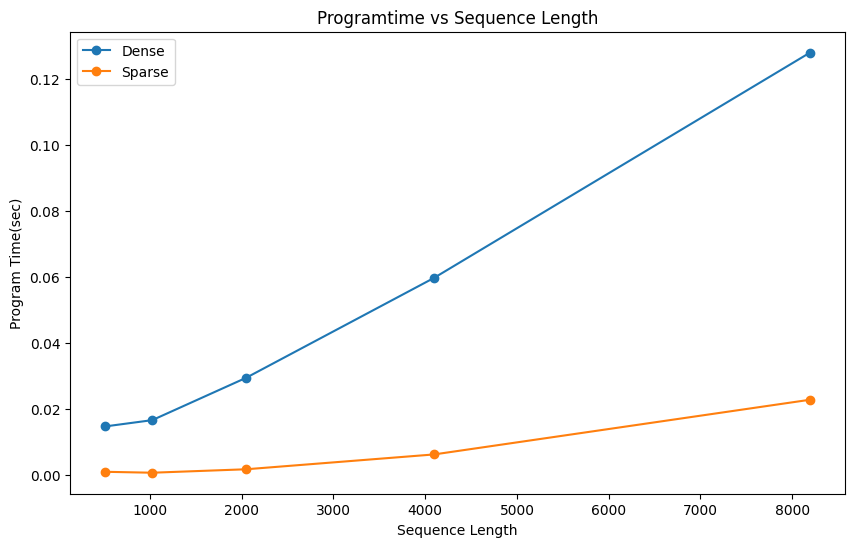

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))
plt.plot(seq,dense_timings,marker='o',label="Dense")
plt.plot(seq,sparse_timings,marker='o',label="Sparse")
plt.xlabel("Sequence Length")
plt.ylabel("Program Time(sec)")
plt.title("Programtime vs Sequence Length")
plt.legend()
plt.show()